In [1]:
import os

cwd = os.getcwd()
new_path = os.path.join(cwd, "backend")
os.chdir(new_path)

In [8]:
from pyrosm import OSM
import geopandas as gpd

bbox = [-87.65, 41.87, -87.60, 41.90]  # west, south, east, north (LIST, not tuple)
pbf = "./data/chicago.osm.pbf"

osm = OSM(pbf, bounding_box=bbox)

In [9]:
buildings = osm.get_buildings()

In [ ]:
drive_net = osm.get_network(network_type="driving")

In [15]:
custom_filter = {
    "landuse": ["park", "recreation_ground"],
    "natural": ["wood", "forest", "grassland"]
}

parks_landuse = osm.get_landuse(custom_filter=custom_filter)


In [16]:
parks_landuse

,landuse,id,timestamp,version,geometry,tags,osm_type,changeset
0,None,354678275,1713815042,3,"POLYGON ((-87.60329 41.8961, -87.60328 41.8961...","{""visible"":false,""natural"":""wood""}",way,NaN
1,None,354678276,1713810547,3,"POLYGON ((-87.60323 41.89402, -87.60321 41.893...","{""visible"":false,""natural"":""wood""}",way,NaN
2,recreation_ground,766114499,1715285459,3,"POLYGON ((-87.61799 41.87068, -87.61802 41.871...","{""visible"":false,""name"":""Lower Hutchinson Field""}",way,NaN
3,recreation_ground,766323331,1579891252,1,"POLYGON ((-87.62208 41.87158, -87.6209 41.8715...","{""visible"":false,""name"":""Upper Hutchinson Field""}",way,NaN
4,None,1255460722,1709093055,2,"POLYGON ((-87.61116 41.89325, -87.61118 41.893...","{""visible"":false,""natural"":""wood""}",way,NaN
5,None,1276540742,1714157523,1,"POLYGON ((-87.63896 41.88904, -87.63901 41.889...","{""visible"":false,""natural"":""wood""}",way,NaN
6,recreation_ground,1281270334,1715285889,1,"POLYGON ((-87.62199 41.87151, -87.62199 41.871...","{""visible"":false,""name"":""Grant Pickleball Cour...",way,NaN
7,recreation_ground,1281270335,1715285889,1,"POLYGON ((-87.62093 41.87116, -87.6215 41.8711...","{""visible"":false,""name"":""Grant Tennis Courts""}",way,NaN
8,recreation_ground,46337210224,1590822153,3,"MULTIPOLYGON (((-87.61891 41.8816, -87.61887 4...","{""name"":""Wave Lawn"",""type"":""multipolygon""}",relation,0.0


In [ ]:
# osmium for defined bbox
# get whatever data you want with tags geometry

In [ ]:
buildings.to_file("./data/buildings.geojson", driver="GeoJSON")
drive_net.to_file("./data/roads.geojson", driver="GeoJSON")
parks_landuse.to_file("./data/parks.geojson", driver="GeoJSON")

In [26]:
buildings.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

<Axes: >

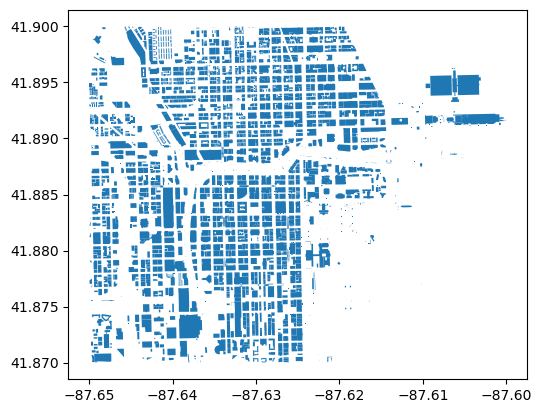

In [27]:
buildings.plot()